<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Enzo Toledo Venegas
- Nombre de alumno 2: Javier Cruz Araneda

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 144 packages in 1ms
Checked 137 packages in 1ms


In [2]:
import warnings

import nltk
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/enzo/Desktop/Lab-MDS/MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [4]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [5]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [6]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [7]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [8]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

1. Un baseline es un modelo de predicciones simples y rápidas que se utiliza como un "punto de partida" y referencia para evaluar el rendimiento de modelos más complejos. En este sentido, un baseline permite saber si un modelo más sofisticado realmente mejora los resultados frente a una regla simple, como por ejemplo, predecir siempre la clase mayoritaria.

2. Un `DummyClassifier` es un clasificador que ignora todas las características de entrada y genera salidas aleatorias como respuesta a las predicciones (o también, genera predicciones siguiendo una regla simple). En este sentido, usar un `DummyClassifier` permite saber si los modelos implementados son mejores que clasificar los datos al azar.

    Si un modelo "real" no logra superar el rendimiento de este baseline, significa que no está extrayendo información útil de los datos, y por tanto posee un problema grave en el proceso de entrenamiento o en cómo se está definiendo el modelo.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [9]:
# Separamos los datos en entrenamiento/prueba (80/20 y estratificado)
X = df_comics.drop(columns=["alignment"])
y = df_comics["alignment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

In [10]:
# Creamos pipeline con preprocesamiento
pipe_dt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

# Entrenamos
pipe_dt.fit(X_train, y_train)

# Generamos predicciones y reporte
y_pred = pipe_dt.predict(X_test)
print("DecisionTreeClassifier: ")
print(classification_report(y_test, y_pred))

DecisionTreeClassifier: 
              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257



In [11]:
# Ahora generamos un DummyClassifier estratificado
dummy_clf = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)

# Generamos predicciones y reporte
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("DummyClassifier:")
print(classification_report(y_test, y_pred_dummy))

DummyClassifier:
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

Según los resultados observados se puede concluir que, en efecto, el DecisionTreeClassifier supera en rendimiento al DummyClassifier en las métricas más importantes. Por ejemplo, el accuracy mejoró de $0.45$ a $0.51$, y el _F1-Macro_ pasó de $0.34$ a $0.39$. Esto indica que el modelo sí ha aprendido patrones útiles del texto y de los atributos numéricos, aunque el margen de leve.

1. El accuracy puede ser engañoso porque las clases están desbalanceadas en el dataset: hay $148$ etiquetados como de "Good", $86$ de "Bad" y solo $23$ de "Neutral". En este sentido, un modelo que predijera siempre "Good" tendría un accuracy razonable, pero sería inútil para detectar "Bad" o "Neutral".

    La métrica más apropiada es el F1-Macro, que trata a todas las clases por igual, sin importar su frecuencia. En este caso, el F1-Macro de $0.39$ del DecisionTree es más "realista" que su accuracy de $0.51$.

2. El parámetro _stratify_ asegura que tanto el conjunto de entrenamiento como el de prueba mantengan la misma proporción de clases que el dataset original. Sin él, la función `train_test_split` podría entregar particiones desbalanceadas (por ejemplo, $80\%$ de las muestras de "Good" en train y $20\%$ en test), lo que sesgaría la evaluación y haría que métricas como accuracy no sean comparables.

3. Como ya se mencionó anteriormente, el DecisionTree tiene un F1-Macro de $0.39$ vs. $0.34$ del DummyClassifier, y por tanto, se puede concluir que, a nivel general, el clasificador es mejor que su versión aleatoria. Sin embargo, no es una mejora contundente, y en particular, se observa que el modelo falla especialmente en predecir la clase "Neutral" (con un rendimiento en la métrica F1 peor que el DummyClassifier). Dicho esto, sí se puede afirmar que se está clasificando mejor que si se tirara un dado de 3 caras.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


En Bagging se crean múltiples subconjuntos del dataset original usando muestreo con reemplazo (bootstrap). Es decir, se toman $n$ muestras del dataset original de forma aleatoria y cada vez que se selecciona una muestra, esta puede seguir siendo seleccionada otra vez en el futuro. En particular, esto significa que algunos datos pueden aparecer múltiples veces en un subconjunto, mientras que otros simplemente no aparecen.

Luego, se entrena un modelo en cada subconjunto generado. Lo importante es que los modelos se entrenan de forma completamente independiente entre sí y en paralelo. Esto lleva a que cada modelo "vea" una versión ligeramente diferente del dataset debido a las muestras repetidas y ausentes.

Para hacer predicciones finales se combinan todas las predicciones de los modelos, en particular, en problemas de clasificación se usa votación mayoritaria (es decir, la clase que más modelos predicen), y en problemas de regresión se promedian las predicciones numéricas.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [12]:
# Creamos pipeline con RandomForestClassifier
pipe_rf = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

# Entrenamos
pipe_rf.fit(X_train, y_train)

# Generamos predicciones y reporte
y_pred_rf = pipe_rf.predict(X_test)

print("RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf))

RandomForestClassifier:
              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

Sí, el Random Forest mejoró respecto al baseline. El accuracy pasó de $0.45$ con DummyClassifier a $0.63$ con Random Forest, lo que es una mejora clara. El F1-Macro también subió de $0.34$ a $0.38$.

Mirando el classification_report, Random Forest se desempeña bien con "Good" (con un rendimiento de $0.75$ en F1) porque tiene un recall muy alto ($0.91$). Sin embargo, tiene problemas serios con las otras clases; "Bad" tiene un rendimiento de $0.40$ en F1, con recall bajo ($0.30$), y "Neutral" directamente falla (con un rendimiento de $0.00$ en F1) porque nunca lo predice.

La razón de esta mejora está en cómo funciona Bagging. Como se describió anteriormente, Random Forest entrena múltiples árboles en subconjuntos aleatorios del dataset y luego vota por mayoría. Esto reduce el sobreajuste comparado con un árbol individual, porque cada árbol ve datos diferentes y los errores tienden a cancelarse entre sí. Por eso el modelo generaliza mejor que el Decision Tree puro y supera el baseline.

Pero el problema de que casi siempre prediga "Good" ocurre porque el dataset está desbalanceado ya que hay muchos más ejemplos de "Good" que de "Bad" o "Neutral". Entonces, aunque Random Forest entrena en subconjuntos aleatorios, la mayoría de esos subconjuntos tienen más ejemplos de "Good", y cuando los árboles votan, "Good" casi siempre gana. Así que la mejora en accuracy viene principalmente de predecir bien la clase mayoritaria.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

A diferencia del Bagging, donde todos los modelos se entrenan de forma independiente y paralela, el Boosting entrena los modelos uno tras otro, de manera secuencial. Cada modelo depende del anterior; primero se entrena uno, se evalúa dónde falla, y luego se entrena el siguiente con información sobre esos errores.

Cada nuevo modelo sabe dónde enfocarse gracias a un sistema de pesos sobre las instancias. Dependiendo del algoritmo utilizado, se modifican los pesos de instancias mal clasificadas cuando el primer modelo comete errores. Por ejemplo, en AdaBoost se aumentan dichos pesos en cada iteración, forzando al modelo siguiente a enfocarse en ellos.

Las predicciones no son una votación simple. Cada modelo tiene un peso según su precisión ya que los modelos que funcionan mejor en entrenamientos contribuyen más a la decisión final. Por tanto, es una combinación ponderada donde los "expertos" que acertaron más tienen más votos.

Aunque XGBoost y LightGBM son implementaciones de Gradient Boosting basadas en árboles de decisión, poseen ligeras diferencias en su diseño y eficiencia. 

Por una parte, XGBoost ofrece mayor flexibilidad ya que maneja automáticamente valores faltantes, incluye regularización L1 y L2 para evitar sobreajuste, y permite definir funciones de optimización personalizadas. Sin embargo, construye los árboles por profundidad (level-wise), lo que lo hace más lento.

Por otra parte, LightGBM está optimizado para velocidad y eficiencia. Usa un algoritmo basado en histogramas que reduce el consumo de memoria, y construye árboles por hoja (leaf-wise), siendo mucho más rápido especialmente con datos grandes.

Finalmente, XGBoost requiere que las etiquetas sean numéricas porque realiza cálculos matemáticos complejos internamente que necesitan valores numéricos. Por el contrario, LightGBM es más flexible y acepta strings directamente, ya que automáticamente convierte las etiquetas de texto a números internamente.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Creamos y ajustamos LabelEncoder para las etiquetas
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [14]:
from xgboost import XGBClassifier

# Creamos pipeline con XGBoost
pipe_xgb = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)

# Entrenamos
pipe_xgb.fit(X_train, y_train_encoded)

# Generamos predicciones y decodificamos
y_pred_xgb_encoded = pipe_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

print("XGBClassifier:")
print(classification_report(y_test, y_pred_xgb))

XGBClassifier:
              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257



In [15]:
# Creamos pipeline con LightGBM
pipe_lgbm = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)

# Entrenamos (LightGBM acepta strings directamente)
pipe_lgbm.fit(X_train, y_train)

# Generamos predicciones
y_pred_lgbm = pipe_lgbm.predict(X_test)

print("LGBMClassifier:")
print(classification_report(y_test, y_pred_lgbm))

LGBMClassifier:
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

Ambos modelos tienen el mismo F1-Macro de $0.45$, que es la métrica que en realidad importa. Aunque LightGBM tiene un accuracy superior ($0.68$ vs $0.63$), esto puede ser engañoso ya que según lo comentado anteriomente el dataset está desbalanceado.

Ambos modelos mejoran significativamente con respecto al baseline, ya que este último tenía un F1-Macro de $0.34$, mientras que XGBoost y LightGBM alcanzan $0.45$. Esto demuestra que ambos capturan información útil del texto y de los atributos numéricos.

Algunas diferencias importantes en el rendimiento son que:

1. LightGBM es mejor con "Bad", ya que posee un F1 de $0.58$ vs $0.47$ de XGBoost.

2. LightGBM falla completamente con "Neutral", ya que posee un F1 de $0.00$, es decir, no lo predice nunca; mientras que XGBoost al menos lo detecta en algunos casos (posee un F1 de $0.14$).

En este sentido, XGBoost es más equilibrado ya que, aunque tenga un accuracy menor, distribuye mejor su error entre todas las clases sin fallar tan dramáticamente en ninguna.

Finalmente, ambos modelos usan Gradient Boosting secuencial, donde cada árbol corrige los errores del anterior. Esto les da ventaja por sobre métodos más simples, permitiendo que ambos lleguen al mismo F1-Macro.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

El Stacking es un método de ensamblaje que combina predicciones de múltiples modelos base mediante un meta-modelo. En este sentido, los modelos base no generan predicciones finales, sino que sus outputs se transforman en nuevas características para el meta-modelo. Para evitar data leakage (predicciones basadas en datos ya vistos), se utiliza validación cruzada interna, es decir, cada modelo base se entrena en $k-1$ folds y genera predicciones sobre el fold restante.

Luego, el meta-modelo recibe como entrada una matriz donde cada columna representa las predicciones de un modelo base diferente. Su función es aprender a combinar de manera óptima estas predicciones para generar la clasificación final. A diferencia de los modelos base, que intentan clasificar directamente a partir de las características originales, el meta-modelo opera en un espacio de predicciones, aprendiendo los puntos fuertes y débiles de cada modelo base.

Si se seleccionara únicamente el mejor modelo individual, se descartaría la información valiosa de los restantes. Stacking aprovecha la _complementariedad_ entre modelos, ya que cada uno comete errores distintos, reflejando fortalezas en clases o patrones diferentes. En este sentido, el meta-modelo aprende a asignar mayor peso a aquellos modelos que son más confiables en cada situación, permitiendo que la combinación supere el desempeño de cualquier componente individual.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

In [17]:
# Definimos los modelos base a ocupar
base_learners = [
    (
        "dt",
        Pipeline([("features", preprocessing_transformer), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    ),
    ("nb", Pipeline([("features", preprocessing_transformer), ("clf", MultinomialNB())])),
    (
        "sgd",
        Pipeline(
            [("features", preprocessing_transformer), ("clf", SGDClassifier(random_state=RANDOM_STATE, max_iter=1000))]
        ),
    ),
]

# Usaremos Regresión Logística como meta-modelo (la justificación está más abajo)
meta_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# Creamos StackingClassifier
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_model, cv=3, n_jobs=-1)

# Entrenamos
stacking_clf.fit(X_train, y_train)

# Generamos predicciones
y_pred_stacking = stacking_clf.predict(X_test)

print("StackingClassifier:")
print(classification_report(y_test, y_pred_stacking))

StackingClassifier:
              precision    recall  f1-score   support

         Bad       0.53      0.38      0.45        86
        Good       0.65      0.85      0.73       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.62       257
   macro avg       0.39      0.41      0.39       257
weighted avg       0.55      0.62      0.57       257



**Justificación:** Se usó como meta-modelo a la Regresión Logística ya que es un modelo simple (considerando que solo tenemos $3$ features) y evita sobreajuste.

### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

Se seleccionaron tres modelos base distintos por su diversidad:

1. DecisionTreeClassifier: Captura patrones no lineales complejos en los datos.

2. MultinomialNB: Especializado en clasificación de texto, ideal para features de bag-of-words.

3. SGDClassifier: Clasificador lineal que aporta una perspectiva diferente a través de optimización estocástica.

El meta-modelo elegido fue Regresión Logística porque, aunque es simple, es suficiente para aprender cómo combinar tres predicciones sin sobreajustarse. Además, evita complejidad innecesaria en un espacio de solo tres features.

Se observa que no hubo una mejora en rendimiento con respecto a los modelos base individuales de las secciones anteriores. En particular, el Stacking alcanzó un F1-Macro de $0.39$, que es igual al DecisionTree pero inferior a XGBoost y LightGBM (ambos con $0.45$). Además, comparte el mismo problema que otros métodos ya que no logra predecir bien la clase "Neutral" (posee un F1 de $0.00$).

Este desempeño limitado puede deberse a que los modelos individuales (DecisionTree, NB, SGD) no son lo suficientemente fuertes como para que el meta-modelo extraiga información valiosa de sus predicciones, ya que si los modelos base cometen errores similares, el meta-modelo puede aprender poco.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

1. Los **hiperparámetros** son configuraciones de modelos que se definen antes del entrenamiento y controlan su aprendizaje y funcionamiento, por ejemplo, `learning_rate` o `max_depth` en LightGBM. Por otro lado, los **parámetros** son aprendidos automáticamente durante el entrenamiento a partir de datos.

2. Es importante la optimización de hiperparámetros pues el rendimiento de un modelo es sensible a esta elección (pudiendo ocurrir subajustes o sobreajustes). En particular, considerando el dataset desbalanceado con el que estamos trabajando la elección de ciertos hiperparámetros es muy importante para aumentar la capacidad de generalización.

3. `GridSearchCV` realiza una busqueda exhaustiva donde el usuario debe definir una grilla de valores posibles para cada hiperparámetro y el algoritmo prueba **todas** las posibles combinaciones mediante validación cruzada. Así, su principal limitación es que con relativamente pocos hiperparámetros su tiempo de ejecución se vuelve muy grande por la cantidad de combinaciones a probar.

4. Es necesario usar validación cruzada (CV) y no el conjunto de testeo para evitar **data leakage** al seleccionar hiperparámetros. Si usaramos el conjunto de testeo estaríamos eligiendo hiperparámetros que funcionen mejor solo para ese subconjunto de datos y perderiamos capacidad de generalización del modelo. Así, si separaramos un conjunto de validación inicial antes de la búsqueda esto sería más rápido que CV (un solo entrenamiento por trial), pero en datasets pequeños como lo es nuestro caso el conjunto de validación es pequeño y podría afectar negativamente el rendimiento del modelo final.

5. Samplers inteligentes como **TPE (Tree-structured Parzen Estimator)** no exploran el espacio de combinaciones de hiperparámetros completo, sino usan el historial de trials anteriores para construir así un modelo probabilístico que estime que regiones de ese espacio podrían dar mejores resultados y enfoca los siguientes trials en esas regiones. Así, esto permite ahorrar combinaciones que CV intentaría igualmente buscando así mejores rangos de hiperparámetros en esta "búsqueda dirigida".

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [18]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [19]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 19. Best value: 0.465027: 100%|██████████| 50/50 [16:56<00:00, 20.34s/it]

Mejor F1-Macro: 0.4650

Mejores hiperparámetros:
  num_leaves: 105
  learning_rate: 0.18313839783098726
  max_depth: 7
  min_child_samples: 20
  subsample: 0.9306106931289139
  colsample_bytree: 0.5852306392660565
  reg_alpha: 2.726398818528333e-07
  reg_lambda: 3.4580541516447337e-06


**Observación:** Ejecución del estudio con optuna en 50 trials se demoró unos **17 minutos** (aprox. 20s/it) 

### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [20]:
import optuna.visualization as ovis

fig1 = ovis.plot_optimization_history(study)
fig1.show()

fig2 = ovis.plot_param_importances(study)
fig2.show()

fig3 = ovis.plot_parallel_coordinate(study)
fig3.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [21]:
pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)

pipe_lgbm_opt.fit(X_train, y_train)

y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

from sklearn.metrics import f1_score

f1_default = f1_score(y_test, y_pred_lgbm, average="macro")
f1_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")

print(f"LightGBM (defaults) F1-Macro:   {f1_default:.4f}")
print(f"LightGBM (optimizado) F1-Macro: {f1_opt:.4f}")
print(f"Mejora: {f1_opt - f1_default:+.4f}")

LightGBM (defaults) F1-Macro:   0.4533
LightGBM (optimizado) F1-Macro: 0.4917
Mejora: +0.0385


### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

> **Respuestas:**

1. Según `plot_param_importances` el hiperparámetro de mayor impacto fue `learning_rate` ($0.91$) con amplia diferencia respecto al segundo (`max_depth` obtuvo $0.06$). Así, esto tiene sentido bajo el contexto de Boosting donde el`learning rate` controla cuanto contribuye cada árbol a la predicción final. Así, un valor demasiado alto provoce overfitting rápidamente, mientras que uno bajo impide al modelo aprender, por tanto, es esencial y esperable que domine como hiperparámetro.

2. Por ejemplo, el `plot_optimization_history` permite ver si el estudio converge efectivamente antes de terminar su ejecución y ver así como fue variando durante su ejecución, por ejemplo, vemos que el objective value aumenta hasta llegar al trial 19 donde no mejora más. Por otro lado, `plot_para_importances` resume la información de los hiperparámetros de mayor importancia, lo que no puede deducirse de ninguna forma de los logs, permitiendo entender mejor qué cosas afectan más o menos al modelo. Finalmente, en el `plot_parallel_coordinate` vemos un mayor detalle en cómo fue ocurriendo la selección de hiperparámetros (usando el drag del hint) a medida que nos acercabamos al objective value de mejor resultado. Así, podemos observar en valores cercanos al máximo que los `learning_rate` testeados oscilaban en torno al óptimo final elegido de $0.18$ aproximadamente, mientras que muchos de los otros hiperparámetros de menor importancia eran más oscilatorios.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [22]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train)

,boosting_type,'gbdt'
,num_leaves,105
,max_depth,7
,learning_rate,0.18313839783098726
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

1. La **PFI (Permutation Feature Importance)** funciona midiendo cuanto decae el rendimiento del modelo al quitar o romper una relación entre un feature y el target del modelo. Así, para cada feature, se permutan aleatoriamente sus valores en el conjunto de evaluación y se mide la diferencia en el rendimiento (por ejemplo en el F1-Macro) entre el modelo original y el evaluado con esa feature permutada. Si la métrica decae mucho, la feature era importante y si ocurre lo contrario entonces lo más probable es que el modelo no dependiera de ella.

2. La importancia nativa de los árboles de decisión tal y como se pudo ver en secciones anteriores tiene un sesgo hacia features de alta cardinalidad o muchos valores únicos, lo que ocurre al tener el árbol más posibilidades de hacer cortes aunque no sean realmente útiles. Así, PFI evita esto porque no mide cuantas veces se usó una feature en el entrenamiento, sino cuánto empeoramiento real hubo en ell rendimiento al eliminar esa información.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [24]:
from sklearn.inspection import permutation_importance
import plotly.express as px

result = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
)

pfi_df = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance": result.importances_mean,
        "std": result.importances_std,
    }
).sort_values("importance", ascending=True)

fig = px.bar(
    pfi_df,
    x="importance",
    y="feature",
    orientation="h",
    error_x="std",
    title="Permutation Feature Importance",
    labels={"importance": "Importancia (F1-Macro)", "feature": "Feature"},
)
fig.show()


### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

1. Observamos primero que todos los features muestran una importancia negativa aunque muy cercana a 0 en algunos casos. Así, las más cercanas al 0 son `power_score` e `intelligence_score`, por tanto, al intercambiar al azar estos puntajes no mejoró ni emepeoró tanto el modelo. Sin embargo, todos los resultados tienen sentido lógico, pues la creación de superhéroes o villanos no se basa o no tiene demasiado sentido pensarlo en base a sus atributos puramente físicos. Así, esto nos indica que **considerar solo atributos físicos (numéricos) de los personajes no permite decir casi nada respecto a su moralidad**. Esto muestra que su historia es la realmente importante (`history_text`).

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

1. Los **SHAP values** miden la contribución individual de cada feature en la predicción de **una** instancia específica. Esto se diferencia de PFI el cual entrega una medida de importancia global, mientras que los SHAP values son locales, lo que es útil para explicar el por qué el modelo predice de cierta forma para un personaje particular y hacer así un análisis más focalizado.

2. El `base_value` representa el valor esperado de las predicciones del modelo sobre el conjunto de entrenamiento, por tanto, es la predicción promedio si no se tuviera información de ninguna feature particular. Esto permite que en el waterfall plot muestre como cada feature aumenta o resta en su contribucción hasta llegar a la predicción final de una cierta instancia.

3. `TreeExplainer` es una implementación particular que calcula SHAP values para modelos basados en árboles, aprovechando su estructura para hacerlo eficientemente. Así, un explainer genérico estima los SHAP values mediante aproximaciones estadísticas que pueden ser muy lentas y poco precisas, mientras que el `TreeExplainer` recorre las ramas del árbol siendo mucho más rápido.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

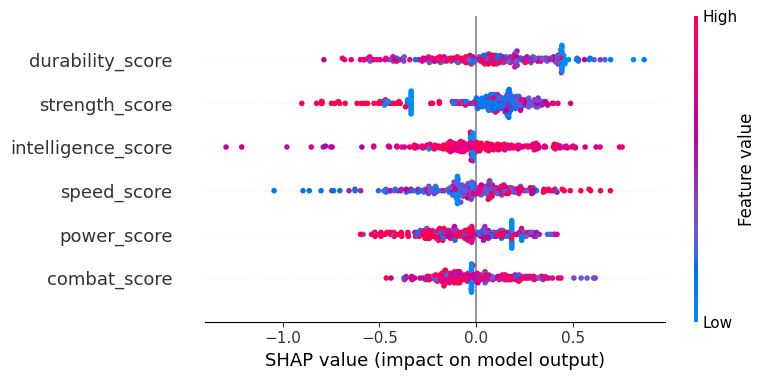

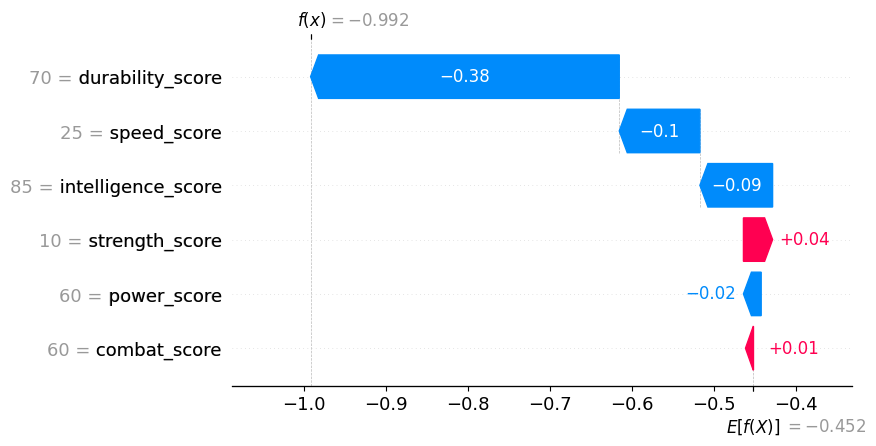

In [30]:
import shap

explainer = shap.TreeExplainer(lgbm_interp)
explanation = explainer(X_test_num)

# Índice de la clase "Good" (clases ordenadas: Bad=0, Good=1, Neutral=2)
good_idx = list(lgbm_interp.classes_).index("Good")

# Summary plot usando directamente explanation segmentado por clase
shap.summary_plot(explanation.values[:, :, good_idx], X_test_num, feature_names=NUMERICAL_FEATURES)

# Waterfall plot: predicción de la primera instancia para la clase 'Good'
shap.plots.waterfall(explanation[0, :, good_idx])

In [37]:
print("El personaje analizado es:", X_test.index[0])

# Buscar el personaje de indice 1303 en el dataframe original para obtener su nombre
personaje_1303 = df_comics.loc[X_test.index[0], "name"]
print("El personaje con índice 1303 es:", personaje_1303)

# Ver su historia:
print("\nHistoria del personaje:")
print(df_comics.loc[X_test.index[0], "history_text"])

El personaje analizado es: 1303
El personaje con índice 1303 es: The Shocker (MCU)

Historia del personaje:
Herman Schultz is a former salvage worker who had become a professional criminal and a member of Adrian Toomes' Crew who had sold Chitauri and Ultron based weaponry created by the Tinkerer. Following Toomes murdering Jackson Brice, who had used his modified gauntlet occasionally under the alias of Shocker, Toomes had passed the gauntlet down onto Schultz and appointed him as the new Shocker. With his new title and power of the gauntlet, Shocker still continued to help Toomes with fighting against Spider-Man's ongoing attempts to bring an end to all of the black market arms deals, which resulted in the Shocker being defeated during a fight and arrested.


### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

1. PFI entrega una medida de importancia global midiendo el como cae el error en todo el conjunto de prueba al romper cierta relación de una variable, mientras SHAP entrega una explicación local, por tanto, nos dice el por qué de la predicción para un individuo particular. mostrando cuanto suma o resta cada valor exacto de sus features partiendo desde el `base_value`.

2. Según el `waterfall_plot` la característica que más empujó la predicción hacia la clase "Good" fue `speed_score` ($+0.7$) y `combat_score` ($+0.12$). Mientras que `durability_score` ($-0.29$) fue la que más penalizó. Investigando sobre el personaje seleccionado, este fue **The Shocker (MCU)**, donde el waterfall_plot revela que atributos físicos como su `speed_score` y `combat_score` empujan fuertemente la predicción hacia la clase "Good" (Héroe). Esto tiene mucho sentido y confirma la conclusión de PFI: al ignorar el texto de su historia (donde **claramente relata ser un criminal y un villano** que pelea contra Spider-Man) y depender exclusivamente de métricas físicas, el modelo se confunde irremediablemente, ya que tanto héroes como villanos suelen compartir puntuaciones muy altas en estadísticas de combate y velocidad y basarse en lo puramente físico no permite decir nada de su moral.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [53]:
df_pred = df_comics_no_label.dropna(subset=["history_text"]).copy()
df_pred["alignment"] = pipe_lgbm_opt.predict(df_pred)

personajes = ["Vergil", "Gorilla Girl", "Batcow"]  # Este es el nombre correcto para encontrarlo en el .csv!
df_pred[df_pred["name"].isin(personajes)][["name", "alignment"]].drop_duplicates()  # batcow sale 2 veces.


,name,alignment
122,Batcow,Good
529,Gorilla Girl,Good
1368,Vergil,Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

In [57]:
def mostrar_personaje(nombre_personaje):
    subset = df_comics_no_label[df_comics_no_label["name"] == nombre_personaje]
    info = subset[
        [
            "intelligence_score",
            "strength_score",
            "speed_score",
            "durability_score",
            "power_score",
            "combat_score",
        ]
    ].iloc[0]
    historia = subset["history_text"].iloc[0]
    print(f"\nPersonaje: {nombre_personaje}")
    print("Estadísticas:")
    print(info)
    print("\nHistoria:")
    print(historia)

In [58]:
mostrar_personaje("Vergil")


Personaje: Vergil
Estadísticas:
intelligence_score     90
strength_score         75
speed_score            95
durability_score       90
power_score           100
combat_score          100
Name: 1368, dtype: int64

Historia:
Vergil, later also known as Nelo Angelo, is one of the main characters in Devil May Cry series, acting as the main antagonist of Devil May Cry 3: Dante's Awakening. He is the twin brother and father of the protagonists, Dante and Nero respectively, and seems designed to be their opposites. Despite being the antagonist, Vergil rarely acted beside Dante.


In [60]:
mostrar_personaje("Gorilla Girl")


Personaje: Gorilla Girl
Estadísticas:
intelligence_score     90
strength_score         35
speed_score            60
durability_score       60
power_score            45
combat_score          100
Name: 529, dtype: int64

Historia:
A carnival performer with the ability to turn into a gorilla, Fahnbullah Eddy and the rest of her fellow performers had their souls stolen by the magician Moondark and turned into his mindless slaves. The carnival was freed from Moondark by Spider-Man and Ghost Rider and their souls returned. Sometime after the incident with Moondark, Eddy and her fellow carnival performers Six and Muck briefly operated as a superhero team called the Freaks. In their only known outing as such, the team saved a doctor from being kidnapped by the villains Hammer and Anvil.


In [61]:
mostrar_personaje("Batcow")


Personaje: Batcow
Estadísticas:
intelligence_score    70
strength_score        10
speed_score           25
durability_score      20
power_score           10
combat_score          20
Name: 122, dtype: int64

Historia:
Bat-Cow was originally a cow that was found by Robin during an investigation on a slaughterhouse, which the cow was sent to. Robin wanted to keep the cow and named it Bat-Cow. Batman decided they would keep the cow. During a later investigation, Batman discovered it had mind-controlling radiation inside of it, leading him to attempt to get rid of the cow. Robin, however would not allow him to hurt the cow. After the events of Robin's death, Bat-Cow and Robin's dog felt a great loss in morale. Alfred Pennyworth and Nightwing had to take care of the cow. Later after Nightwing's disappearance, Alfred was the only caretaker of Bat-Cow. Bat-Cow, complete with cape, spent time on a Wayne Enterprises-owned dairy farm. It was there the cow encountered the cosmic-powered "Forever 

**Respuesta:**

1. Las predicciones obtenidas (todas como "Good") son parcialmente razonables. Por un lado, Gorilla Girl y Bat-Cow son efectivamente aliados u héroes y sus historias revelan acciones positivas asociados al bien más que al mal. Sin embargo, el caso de Vergil es incorrecto, ya que su historia indica claramente que es el "main antagonist".

2. Según lo aprendido con el `waterfall_plot` en la sección 4, características físicas altas (como `speed_score` y `combat_score`) son factores que empujan fuertemente la predicción hacia la clase "Good". En el caso de **Bat-Cow**, sus métricas numéricas son bajísimas (ej: combat_score 20, power_score 10). Debido a esto, el modelo puramente numérico probablemente la clasificaría como "Bad" o la penalizaría. Sin embargo, en esta sección logramos predecirla correctamente como "Good", lo cual es totalmente **consistente**, ya que demuestra el poder del modelo de texto (`history_text`): al leer palabras fuertes como "Robin", "Batman" y "Wayne", el modelo superó sus malos puntajes numéricos y capturó correctamente su moralidad.

> 🦇🐄

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>